# Выбор базовой модели

Использую датасет из курсовой: https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset

Решите задачи с использованием стандратных классов RandomForest ExtraTrees LightGBM XGBoost

In [7]:
import pandas as pd

data_clf = pd.read_csv('diabetes_prediction_dataset.csv')

data_clf['gender'] = data_clf['gender'].map({'Male': 1, 'Female': 0})
smoking_map = {'never': 0, 'No Info': 1, 'current': 2, 'former': 3, 'ever': 4, 'not current': 5}
data_clf['smoking_history'] = data_clf['smoking_history'].map(smoking_map)

target_clf = 'diabetes'
features_clf = data_clf.columns.drop(target_clf)
data_clf = data_clf.dropna()

X_clf = data_clf[features_clf]
y_clf = data_clf[target_clf]

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)


In [10]:
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import balanced_accuracy_score, precision_score, recall_score, f1_score, classification_report

In [ ]:
rf_clf = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)
et_clf = ExtraTreesClassifier(n_estimators=100, random_state=42)

rf_clf.fit(X_train_clf, y_train_clf)
et_clf.fit(X_train_clf, y_train_clf)

rf_clf_accuracy = balanced_accuracy_score(y_test_clf, rf_clf.predict(X_test_clf))
rf_clf_precision = precision_score(y_test_clf, rf_clf.predict(X_test_clf), average='binary')  # Для бинарной классификации
rf_clf_recall = recall_score(y_test_clf, rf_clf.predict(X_test_clf), average='binary')
rf_clf_f1 = f1_score(y_test_clf, rf_clf.predict(X_test_clf), average='binary')

et_clf_accuracy = balanced_accuracy_score(y_test_clf, et_clf.predict(X_test_clf))
et_clf_precision = precision_score(y_test_clf, et_clf.predict(X_test_clf), average='binary')  # Для бинарной классификации
et_clf_recall = recall_score(y_test_clf, et_clf.predict(X_test_clf), average='binary')
et_clf_f1 = f1_score(y_test_clf, et_clf.predict(X_test_clf), average='binary')

print(f"RandomForest Classifier Accuracy: {rf_clf_accuracy}")
print(f"RandomForest Classifier Precision: {rf_clf_precision}")
print(f"RandomForest Classifier Recall: {rf_clf_recall}")
print(f"RandomForest Classifier F1-Score: {rf_clf_f1}")
print(classification_report(y_test_clf,rf_clf.predict(X_test_clf)))

print(f"ExtraTrees Classifier Accuracy: {et_clf_accuracy}")
print(f"ExtraTrees Classifier Precision: {et_clf_precision}")
print(f"ExtraTrees Classifier Recall: {et_clf_recall}")
print(f"ExtraTrees Classifier F1-Score: {et_clf_f1}")
print(classification_report(y_test_clf,et_clf.predict(X_test_clf)))
#print(f"RandomForest Classifier OOB Score: {rf_clf.oob_score_}")

RandomForest Classifier Accuracy: 0.8325033273202556
RandomForest Classifier Precision: 0.949874686716792
RandomForest Classifier Recall: 0.6684303350970018
RandomForest Classifier F1-Score: 0.7846790890269151
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17525
           1       0.95      0.67      0.78      1701

    accuracy                           0.97     19226
   macro avg       0.96      0.83      0.88     19226
weighted avg       0.97      0.97      0.96     19226

ExtraTrees Classifier Accuracy: 0.8302978276603257
ExtraTrees Classifier Precision: 0.89944576405384
ExtraTrees Classifier Recall: 0.6678424456202234
ExtraTrees Classifier F1-Score: 0.766531713900135
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     17525
           1       0.90      0.67      0.77      1701

    accuracy                           0.96     19226
   macro avg       0.93      0.83      0.87  

LightGBM и XGBoost

In [ ]:
from sklearn.metrics import accuracy_score
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# LightGBM Classifier
lgbm_clf = LGBMClassifier(n_estimators=100, random_state=42)
lgbm_clf.fit(X_train_clf, y_train_clf)
lgbm_accuracy = balanced_accuracy_score(y_test_clf, lgbm_clf.predict(X_test_clf))
lgbm_precision = precision_score(y_test_clf, lgbm_clf.predict(X_test_clf), average='binary')  # Для бинарной классификации
lgbm_recall = recall_score(y_test_clf, lgbm_clf.predict(X_test_clf), average='binary')
lgbm_f1 = f1_score(y_test_clf, lgbm_clf.predict(X_test_clf), average='binary')

print(f"LightGBM Classifier Accuracy: {lgbm_accuracy}")
print(f"LightGBM Classifier Precision: {lgbm_precision}")
print(f"LightGBM Classifier Recall: {lgbm_recall}")
print(f"LightGBM Classifier F1-Score: {lgbm_f1}")
print(classification_report(y_test_clf,lgbm_clf.predict(X_test_clf)))

# XGBoost Classifier
xgb_clf = XGBClassifier(n_estimators=100, use_label_encoder=False, random_state=42)
xgb_clf.fit(X_train_clf, y_train_clf)
xgb_accuracy = balanced_accuracy_score(y_test_clf, xgb_clf.predict(X_test_clf))
xgb_precision = precision_score(y_test_clf, xgb_clf.predict(X_test_clf), average='binary')  # Для бинарной классификации
xgb_recall = recall_score(y_test_clf, xgb_clf.predict(X_test_clf), average='binary')
xgb_f1 = f1_score(y_test_clf, xgb_clf.predict(X_test_clf), average='binary')

print(f"XGBoost Classifier Accuracy: {xgb_accuracy}")
print(f"XGBoost Classifier Precision: {xgb_precision}")
print(f"XGBoost Classifier Recall: {xgb_recall}")
print(f"XGBoost Classifier F1-Score: {xgb_f1}")
print(classification_report(y_test_clf,xgb_clf.predict(X_test_clf)))

[LightGBM] [Info] Number of positive: 6781, number of negative: 70121
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002045 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 386
[LightGBM] [Info] Number of data points in the train set: 76902, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.088177 -> initscore=-2.336098
[LightGBM] [Info] Start training from score -2.336098
LightGBM Classifier Accuracy: 0.8338814375365334
LightGBM Classifier Precision: 0.9810344827586207
LightGBM Classifier Recall: 0.6690182245737801
LightGBM Classifier F1-Score: 0.7955260398462076
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17525
           1       0.98      0.67      0.80      1701

    accuracy                           0.97     19226
   macro avg       0.97      0.8

C:\Users\ivank\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xgboost\core.py:158: UserWarning: [13:29:06] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Classifier Accuracy: 0.8349404772387812
XGBoost Classifier Precision: 0.9525790349417638
XGBoost Classifier Recall: 0.6731334509112287
XGBoost Classifier F1-Score: 0.7888391319324837
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17525
           1       0.95      0.67      0.79      1701

    accuracy                           0.97     19226
   macro avg       0.96      0.83      0.89     19226
weighted avg       0.97      0.97      0.97     19226



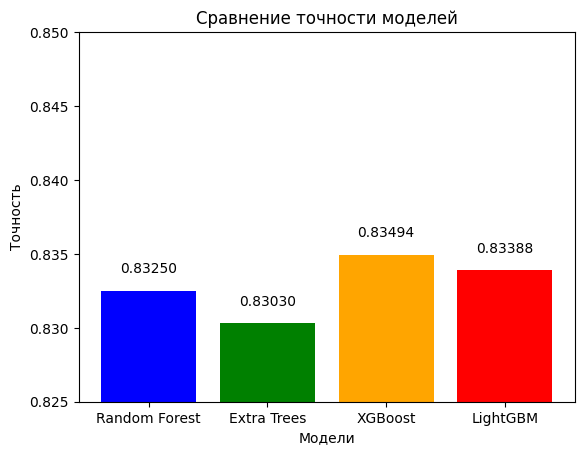

In [ ]:
import matplotlib.pyplot as plt

models = ['Random Forest', 'Extra Trees', 'XGBoost', 'LightGBM']
accuracy = [rf_clf_accuracy, et_clf_accuracy, xgb_accuracy, lgbm_accuracy]

plt.bar(models, accuracy, color=['blue', 'green', 'orange', 'red'])
plt.xlabel('Модели')
plt.ylabel('Точность')
plt.title('Сравнение точности моделей')
plt.ylim(0.825, 0.85)  # Для наглядности

# Добавляем значения над столбиками
for i, value in enumerate(accuracy):
    plt.text(i, value + 0.001, f'{value:.5f}', ha='center', va='bottom')

plt.show()

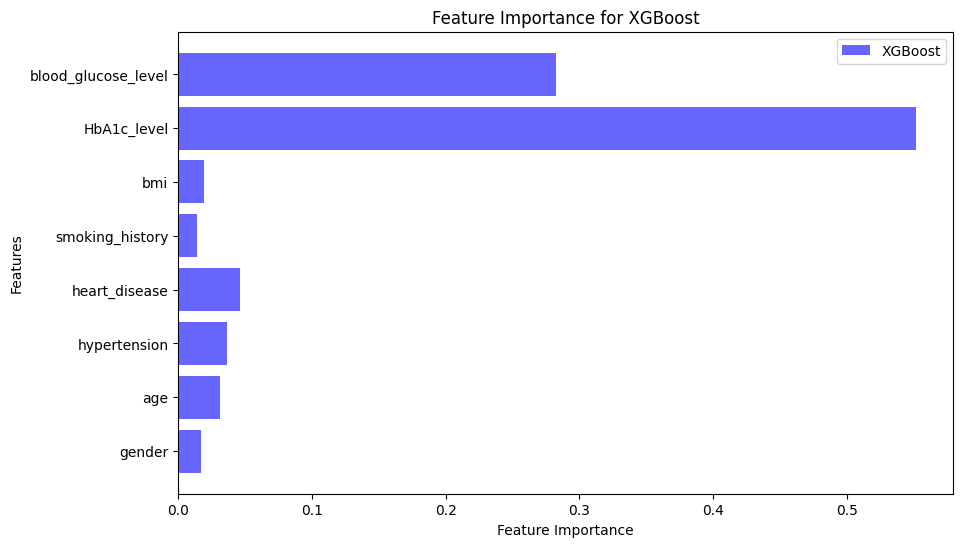

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(features_clf, xgb_clf.feature_importances_, color='blue', alpha=0.6, label="XGBoost")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance for XGBoost")
plt.legend()
plt.show()

Text(0.5, 1.0, 'Scatter Plot for HbA1c_level VS blood_glucose_level')

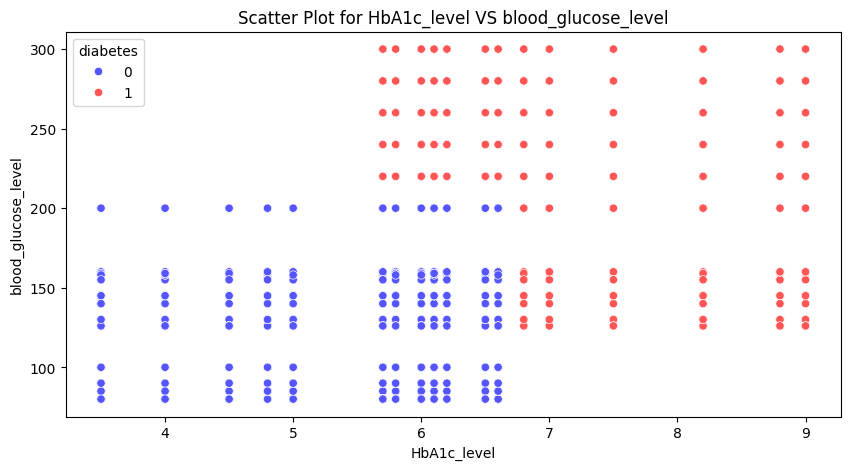

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize = (10, 5)) #фигура + координатная плоскость
#Строим диаграмму рассеяния
sns.scatterplot(
    data=data_clf, #датасет
    x='HbA1c_level', #ось абсцисс
    y='blood_glucose_level', #ось ординат
    hue='diabetes', #группировка
    palette='seismic', #палитра
    ax=ax, #координатная плоскость
);
#Задаём название графика
ax.set_title('Scatter Plot for HbA1c_level VS blood_glucose_level')